In [9]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")

print("Train Shape:", train.shape)
print("Store Shape:", store.shape)

Train Shape: (1017209, 9)
Store Shape: (1115, 10)


/var/folders/qf/k3_sss794675018bjvh4fyr40000gn/T/ipykernel_36518/3655959512.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


In [10]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [7]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [11]:
df = train.merge(store, on="Store", how="left")

print(df.shape)
df.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [12]:
missing_percent = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      * 100
)

missing_percent

PromoInterval                49.943620
Promo2SinceYear              49.943620
Promo2SinceWeek              49.943620
CompetitionOpenSinceYear     31.787764
CompetitionOpenSinceMonth    31.787764
CompetitionDistance           0.259730
DayOfWeek                     0.000000
Promo2                        0.000000
Assortment                    0.000000
Store                         0.000000
SchoolHoliday                 0.000000
StateHoliday                  0.000000
Promo                         0.000000
Open                          0.000000
Customers                     0.000000
Sales                         0.000000
Date                          0.000000
StoreType                     0.000000
dtype: float64

In [13]:
df["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [14]:
df.groupby("Open")["Sales"].mean()

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

In [15]:
df["Open"].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [16]:
df = df[df["Open"] == 1]

print(df.shape)

(844392, 18)


In [17]:
df.groupby("Promo")["Sales"].mean()

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

In [18]:
df.groupby("StoreType")["Sales"].mean().sort_values(ascending=False)

StoreType
b    10231.407505
c     6932.512755
a     6925.167661
d     6822.141881
Name: Sales, dtype: float64

In [19]:
df.groupby("DayOfWeek")["Sales"].mean()

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64

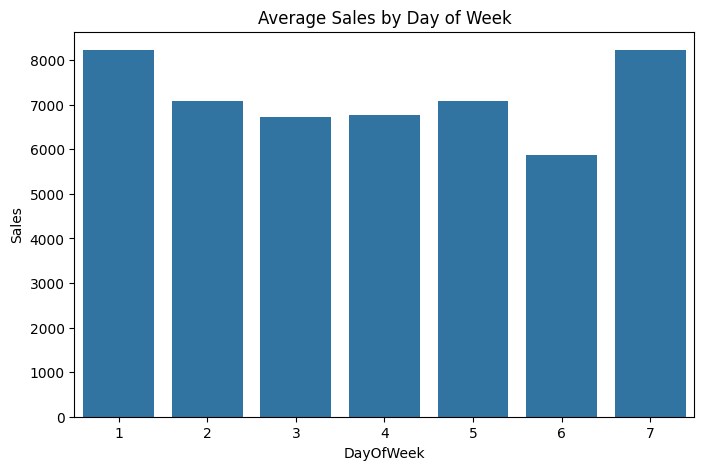

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_by_day = df.groupby("DayOfWeek")["Sales"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=sales_by_day, x="DayOfWeek", y="Sales")
plt.title("Average Sales by Day of Week")
plt.show()

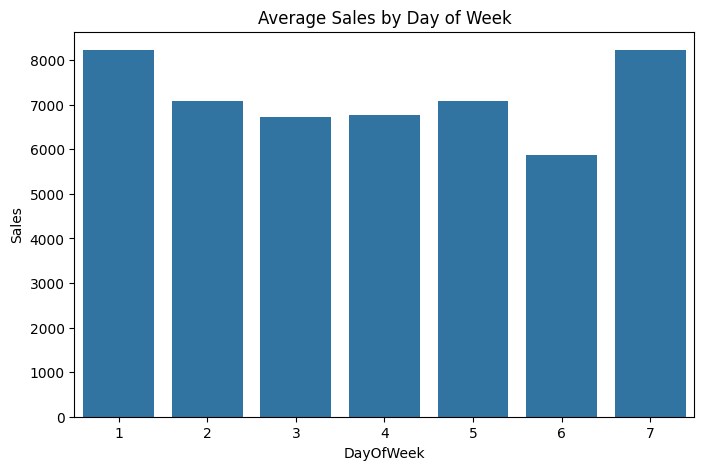

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=sales_by_day, x="DayOfWeek", y="Sales")
plt.title("Average Sales by Day of Week")

plt.savefig("../images/avg_sales_dayofweek.png",
            bbox_inches="tight")

plt.show()

In [20]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [21]:
df.groupby("Month")["Sales"].mean()

Month
1     6563.690444
2     6589.165535
3     6976.412026
4     7046.228420
5     7106.453154
6     7000.978190
7     6952.682125
8     6648.984654
9     6546.343035
10    6602.843354
11    7188.554250
12    8608.956661
Name: Sales, dtype: float64

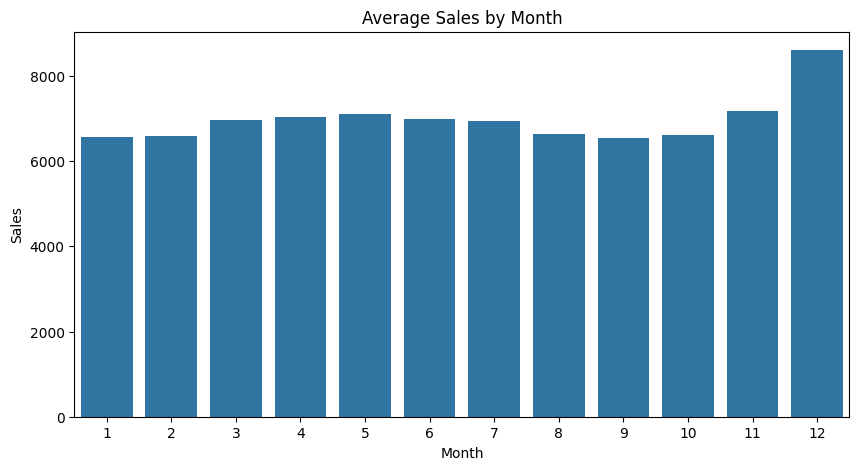

In [22]:
monthly_sales = df.groupby("Month")["Sales"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_sales, x="Month", y="Sales")
plt.title("Average Sales by Month")

plt.savefig(
    "../images/avg_sales_month.png",
    bbox_inches="tight"
)

plt.show()

In [22]:
df.groupby("Year")["Sales"].mean()

Year
2013    6814.392025
2014    7025.404201
2015    7088.126648
Name: Sales, dtype: float64

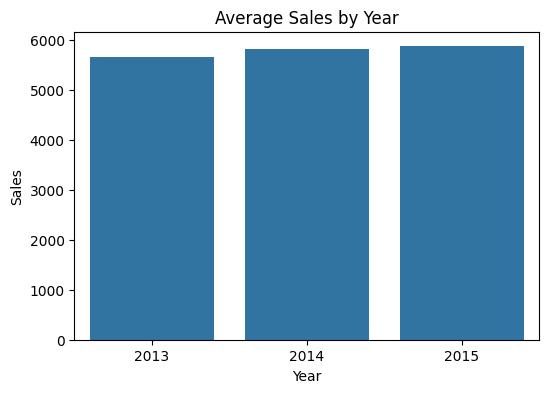

In [7]:
yearly_sales = df.groupby("Year")["Sales"].mean().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=yearly_sales, x="Year", y="Sales")
plt.title("Average Sales by Year")

plt.savefig(
    "../images/avg_sales_year.png",
    bbox_inches="tight"
)

plt.show()

In [8]:
df.isnull().sum().sort_values(ascending=False)

PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
Store                             0
Month                             0
Year                              0
Promo2                            0
Assortment                        0
DayOfWeek                         0
StoreType                         0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Sales                             0
Date                              0
Day                               0
dtype: int64

In [23]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
    df["CompetitionDistance"].median()
)

df["CompetitionOpenSinceMonth"] = (
    df["CompetitionOpenSinceMonth"].fillna(0)
)

df["CompetitionOpenSinceYear"] = (
    df["CompetitionOpenSinceYear"].fillna(0)
)

df["Promo2SinceWeek"] = (
    df["Promo2SinceWeek"].fillna(0)
)

df["Promo2SinceYear"] = (
    df["Promo2SinceYear"].fillna(0)
)

df["PromoInterval"] = (
    df["PromoInterval"].fillna("None")
)

In [24]:
df.isnull().sum().sum()

np.int64(0)

In [25]:
df["Quarter"] = df["Date"].dt.quarter

In [26]:
df[["Date", "Quarter"]].head()

,Date,Quarter
0,2015-07-31,3
1,2015-07-31,3
2,2015-07-31,3
3,2015-07-31,3
4,2015-07-31,3


In [27]:
df["IsWeekend"] = (
    df["DayOfWeek"].isin([6, 7])
).astype(int)

In [29]:
df[["DayOfWeek", "IsWeekend"]].head()

,DayOfWeek,IsWeekend
0,5,0
1,5,0
2,5,0
3,5,0
4,5,0


In [30]:
df["CompetitionOpenDate"] = pd.to_datetime(
    dict(
        year=df["CompetitionOpenSinceYear"],
        month=df["CompetitionOpenSinceMonth"].replace(0, 1),
        day=1
    ),
    errors="coerce"
)

In [31]:
df["CompetitionAge"] = (
    (df["Date"] - df["CompetitionOpenDate"])
    .dt.days
)

In [32]:
df["CompetitionAge"] = (
    df["CompetitionAge"]
    .clip(lower=0)
)

In [33]:
promo_date = (
    df["Promo2SinceYear"].astype(int).astype(str)
    + "-"
    + df["Promo2SinceWeek"].astype(int).astype(str)
    + "-1"
)

df["PromoStartDate"] = pd.to_datetime(
    promo_date,
    format="%Y-%W-%w",
    errors="coerce"
)

In [34]:
df["PromoAge"] = (
    (df["Date"] - df["PromoStartDate"])
    .dt.days
)

In [35]:
df["PromoAge"] = (
    df["PromoAge"]
    .clip(lower=0)
    .fillna(0)
)

In [36]:
df[
    [
        "Quarter",
        "IsWeekend",
        "CompetitionAge",
        "PromoAge"
    ]
].head()

,Quarter,IsWeekend,CompetitionAge,PromoAge
0,3,0,2524.0,0.0
1,3,0,2829.0,1950.0
2,3,0,3164.0,1579.0
3,3,0,2159.0,0.0
4,3,0,121.0,0.0


In [37]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,PromoInterval,Year,Month,Day,Quarter,IsWeekend,CompetitionOpenDate,CompetitionAge,PromoStartDate,PromoAge
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,None,2015,7,31,3,0,2008-09-01,2524.0,NaT,0.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,"Jan,Apr,Jul,Oct",2015,7,31,3,0,2007-11-01,2829.0,2010-03-29,1950.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,"Jan,Apr,Jul,Oct",2015,7,31,3,0,2006-12-01,3164.0,2011-04-04,1579.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,None,2015,7,31,3,0,2009-09-01,2159.0,NaT,0.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,None,2015,7,31,3,0,2015-04-01,121.0,NaT,0.0


In [38]:
df.columns.tolist()

df.sample(5)

df[
    [
        "Store",
        "Date",
        "Sales",
        "Customers",
        "Promo",
        "StoreType",
        "CompetitionAge",
        "PromoAge"
    ]
].head(10)

,Store,Date,Sales,Customers,Promo,StoreType,CompetitionAge,PromoAge
0,1,2015-07-31,5263,555,1,c,2524.0,0.0
1,2,2015-07-31,6064,625,1,a,2829.0,1950.0
2,3,2015-07-31,8314,821,1,a,3164.0,1579.0
3,4,2015-07-31,13995,1498,1,c,2159.0,0.0
4,5,2015-07-31,4822,559,1,a,121.0,0.0
5,6,2015-07-31,5651,589,1,a,607.0,0.0
6,7,2015-07-31,15344,1414,1,a,851.0,0.0
7,8,2015-07-31,8492,833,1,a,303.0,0.0
8,9,2015-07-31,8565,687,1,a,5477.0,0.0
9,10,2015-07-31,7185,681,1,a,2159.0,0.0


In [39]:
numeric_cols = df.select_dtypes(include="number")

numeric_cols.corr()["Sales"].sort_values(
    ascending=False
)

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
Month                        0.073600
Quarter                      0.062011
SchoolHoliday                0.038617
Year                         0.036169
Store                        0.007710
CompetitionOpenSinceYear     0.005266
CompetitionAge              -0.007567
CompetitionOpenSinceMonth   -0.018370
CompetitionDistance         -0.035850
Day                         -0.051849
Promo2SinceWeek             -0.058476
PromoAge                    -0.061076
Promo2                      -0.127596
Promo2SinceYear             -0.127621
IsWeekend                   -0.151780
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

In [40]:
df.select_dtypes(include="object").columns

/var/folders/qf/k3_sss794675018bjvh4fyr40000gn/T/ipykernel_36518/1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='str')

In [41]:
df = pd.get_dummies(
    df,
    columns=[
        "StoreType",
        "Assortment",
        "StateHoliday",
        "PromoInterval"
    ],
    drop_first=True
)

In [6]:
df.shape

(1017209, 25)

In [42]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StoreType_d,Assortment_b,Assortment_c,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_None
0,1,5,2015-07-31,5263,555,1,1,1,1270.0,9.0,...,False,False,False,True,False,False,False,False,False,True
1,2,5,2015-07-31,6064,625,1,1,1,570.0,11.0,...,False,False,False,True,False,False,False,True,False,False
2,3,5,2015-07-31,8314,821,1,1,1,14130.0,12.0,...,False,False,False,True,False,False,False,True,False,False
3,4,5,2015-07-31,13995,1498,1,1,1,620.0,9.0,...,False,False,True,True,False,False,False,False,False,True
4,5,5,2015-07-31,4822,559,1,1,1,29910.0,4.0,...,False,False,False,True,False,False,False,False,False,True


In [43]:
df.columns.tolist()

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'SchoolHoliday',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'Year',
 'Month',
 'Day',
 'Quarter',
 'IsWeekend',
 'CompetitionOpenDate',
 'CompetitionAge',
 'PromoStartDate',
 'PromoAge',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_b',
 'Assortment_c',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'PromoInterval_Jan,Apr,Jul,Oct',
 'PromoInterval_Mar,Jun,Sept,Dec',
 'PromoInterval_None']

In [44]:
df = df.drop(
    columns=[
        "Date",
        "CompetitionOpenDate",
        "PromoStartDate"
    ],
    errors="ignore"
)

In [45]:
df.shape

(844392, 32)

In [46]:
y = df["Sales"]

X = df.drop(
    columns=[
        "Sales",
        "Date",
        "CompetitionOpenDate",
        "PromoStartDate"
    ],
    errors="ignore"
)

print(X.shape)
print(y.shape)

(844392, 31)
(844392,)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (675513, 31)
Test : (168879, 31)


In [48]:
from xgboost import XGBRegressor

In [49]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [50]:
y_pred = model.predict(X_test)

In [51]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 331.9838562011719
RMSE: 474.44701363798254
R²  : 0.9766584634780884


In [52]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
22,Assortment_b,0.233600
2,Customers,0.227353
21,StoreType_d,0.153607
19,StoreType_b,0.113266
4,Promo,0.048779
23,Assortment_c,0.022649
9,Promo2,0.021899
6,CompetitionDistance,0.020374
11,Promo2SinceYear,0.014211
10,Promo2SinceWeek,0.013901


In [53]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
377759,5203,4636.612305
865636,8590,8089.886719
114355,6465,6349.221680
9537,7250,6677.515137
549094,4339,4507.102051
640525,4221,4330.343750
656515,5258,5329.679199
493564,6882,6473.660645
137518,10413,10637.698242
947722,7090,8378.492188


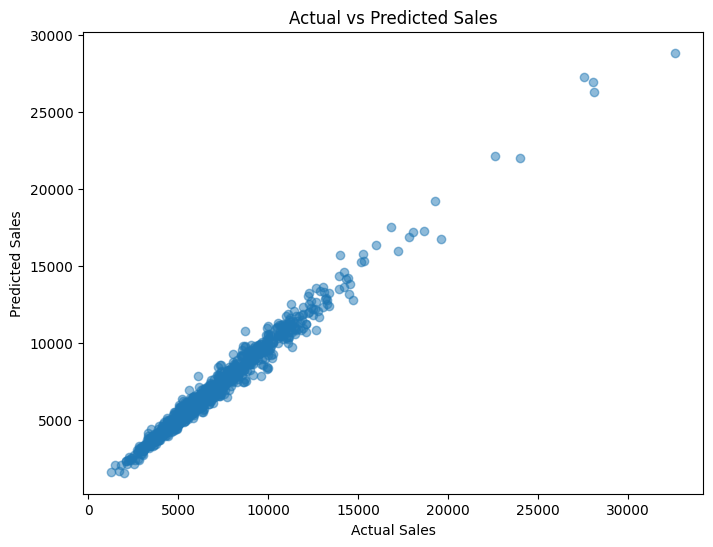

In [54]:
import matplotlib.pyplot as plt

sample = comparison.sample(1000, random_state=42)

plt.figure(figsize=(8,6))

plt.scatter(
    sample["Actual"],
    sample["Predicted"],
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [55]:
comparison["Residual"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

comparison["Residual"].describe()

count    168879.000000
mean          0.964200
std         474.447417
min       -7602.531250
25%        -262.862549
50%         -19.110596
75%         235.941772
max       18198.649414
Name: Residual, dtype: float64

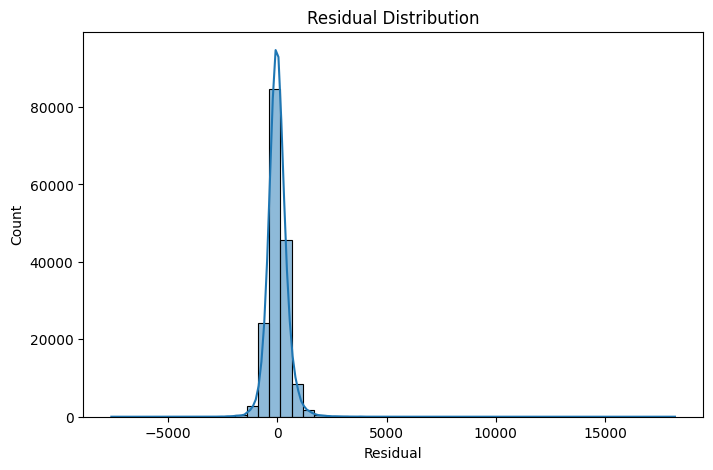

In [56]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    comparison["Residual"],
    bins=50,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual")

plt.show()

In [57]:
import joblib

joblib.dump(model, "../models/xgb_model.pkl")

['../models/xgb_model.pkl']

In [58]:
joblib.dump(
    X.columns.tolist(),
    "../models/features.pkl"
)

['../models/features.pkl']

In [59]:
import os

os.listdir("../models")

['features.pkl', 'xgb_model.pkl']

In [1]:
feature_importance.to_csv(
    "data/feature_importance.csv",
    index=False
)

NameError: name 'feature_importance' is not defined

In [2]:
feature_importance

NameError: name 'feature_importance' is not defined

In [3]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head()

NameError: name 'X' is not defined

In [4]:
import joblib

model = joblib.load("../models/xgb_model.pkl")

features = joblib.load("../models/features.pkl")

print(len(features))
print(features[:5])

31
['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo']


In [5]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
22,Assortment_b,0.233600
2,Customers,0.227353
21,StoreType_d,0.153607
19,StoreType_b,0.113266
4,Promo,0.048779
23,Assortment_c,0.022649
9,Promo2,0.021899
6,CompetitionDistance,0.020374
11,Promo2SinceYear,0.014211
10,Promo2SinceWeek,0.013901


In [6]:
feature_importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

In [9]:
print(features)

['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'Quarter', 'IsWeekend', 'CompetitionAge', 'PromoAge', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None']
